In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import json
import math
import statistics as st
from collections import Counter

from uq_pet.config import LLM_SCORES_DIR, NER_TAGS
from uq_pet.dataset import split_dataset

N_FEW_SHOT, FEW_SHOT_SEED = 1, 13
CACHE = LLM_SCORES_DIR / "nhr_oss_pool_fs1s13_topk2.json"
ARM_PARAMS = {"random": {"seed": 13}}  # the control's `seed:` knob, from the same config
BUDGET_PCT = 10  # the budget where the gap to random is widest

_, pool, test = split_dataset(n_few_shot=N_FEW_SHOT, few_shot_seed=FEW_SHOT_SEED)

In [17]:
import re

import pandas as pd

from uq_pet.config import RESULTS_DIR
from uq_pet.dataset import sentence_key, to_examples

# results/<config stem>_<YYYYmmdd>_<HHMMSS>/. Directories from before run dirs were
# timestamped keep their whole name as the stem rather than losing half of it.
RUN_STAMP = re.compile(r"_\d{8}_\d{6}$")
# What this notebook reads. Older runs wrote a different set of files, so "has a
# metrics.json" is not enough to call a directory usable here.
NEEDED = ("results.csv", "selection.json", "metrics.json")


def run_dirs() -> dict[str, list]:
    """Config stem -> its usable run directories, newest first."""
    runs: dict[str, list] = {}
    for path in sorted(RESULTS_DIR.glob("*/"), reverse=True):
        if all((path / f).exists() for f in NEEDED):
            runs.setdefault(RUN_STAMP.sub("", path.name), []).append(path)
    return runs


def latest_run(stem: str):
    """The most recent usable run of one config."""
    paths = run_dirs().get(stem)
    if not paths:
        raise FileNotFoundError(f"no usable run for {stem!r} in {RESULTS_DIR}")
    return paths[0]


RUN_DIR = latest_run("nhr_gpt_oss_topk")
selection = json.loads((RUN_DIR / "selection.json").read_text())

# Sentence length = number of PET tokens. Keyed the same way selection.json is, so a
# selected key looks its length up directly.
pool_examples = to_examples(pool)
length = {sentence_key(ex): len(ex["tokens"]) for ex in pool_examples}
RUN_DIR

PosixPath('/Users/mac/Developer/VScode/uq-pet/results/nhr_gpt_oss_topk_20260804_180335')

In [18]:
def length_stats(name: str, budget: str | None, keys: list[str]) -> dict:
    lengths = [length[k] for k in keys]
    return {
        "budget_pct": budget,
        "arm": name,
        "n": len(lengths),
        "mean": st.fmean(lengths),
        "median": st.median(lengths),
        "sd": st.stdev(lengths),
        "min": min(lengths),
        "max": max(lengths),
    }


rows = [length_stats("POOL", None, list(length))]
rows += [
    length_stats(arm, budget, keys)
    for budget, arms in selection.items()
    for arm, keys in arms.items()
]
lengths_df = pd.DataFrame(rows)

# How far each arm's mean sits from the pool mean, in pool standard deviations —
# a 33-sentence draw is small, so raw differences are easy to over-read.
pool_mean, pool_sd = lengths_df.loc[0, "mean"], lengths_df.loc[0, "sd"]
lengths_df["vs_pool"] = lengths_df["mean"] - pool_mean
lengths_df["z_of_mean"] = lengths_df["vs_pool"] / (pool_sd / lengths_df["n"] ** 0.5)

lengths_df.round(2)

,budget_pct,arm,n,mean,median,sd,min,max,vs_pool,z_of_mean
0,NaN,POOL,332,17.92,17.0,8.00,6,51,0.00,0.00
1,10,random,33,20.18,19.0,7.57,7,36,2.27,1.63
2,10,avg_neg_logprob_filtered,33,23.91,24.0,9.35,9,51,5.99,4.30
3,10,vote_entropy,33,21.85,20.0,10.20,6,51,3.93,2.82
4,10,pairwise_f1_disagreement,33,21.30,22.0,8.18,6,40,3.39,2.43
5,10,entity_count_std,33,26.33,27.0,7.08,10,40,8.42,6.04
6,10,least_confident,33,25.52,24.0,8.58,10,51,7.60,5.46
7,10,length,33,33.06,33.0,4.24,29,51,15.14,10.87
8,10,confident:avg_neg_logprob_filtered,33,15.00,13.0,6.65,6,29,-2.92,-2.09
9,20,random,66,19.30,18.5,8.31,7,49,1.39,1.41


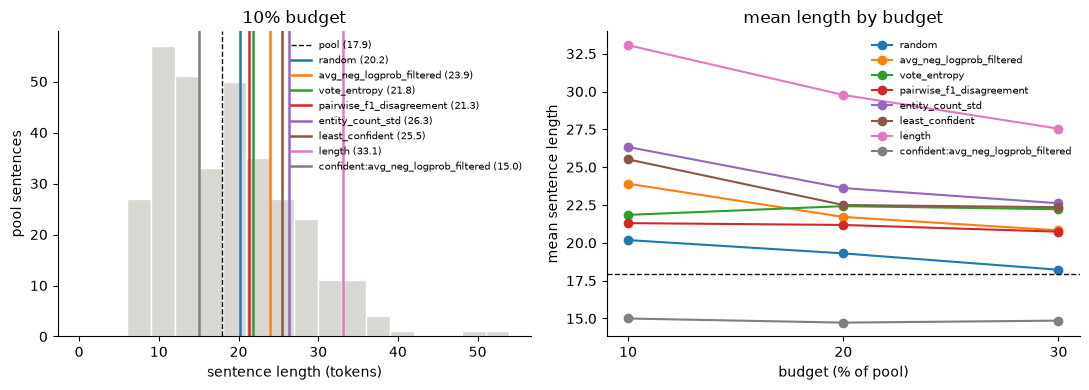

In [19]:
import matplotlib.pyplot as plt

from uq_pet.plotting import INK_SECONDARY, SURFACE, arm_colors

arms = list(selection[str(BUDGET_PCT)])
colors = arm_colors(arms)
budgets = list(selection)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), facecolor=SURFACE)

# Left: the pool's length distribution with each arm's mean at the smallest budget.
ax = axes[0]
ax.hist(list(length.values()), bins=range(0, 56, 3), color="#d8d7d2", edgecolor=SURFACE)
ax.axvline(pool_mean, color=INK_SECONDARY, ls="--", lw=1, label=f"pool ({pool_mean:.1f})")
for arm in arms:
    mean = st.fmean(length[k] for k in selection[str(BUDGET_PCT)][arm])
    ax.axvline(mean, color=colors[arm], lw=1.8, label=f"{arm} ({mean:.1f})")
ax.set(xlabel="sentence length (tokens)", ylabel="pool sentences", title=f"{BUDGET_PCT}% budget")
ax.legend(fontsize=7, frameon=False)

# Right: does the skew survive as the budget grows? By 30% each arm holds a third of
# the pool, so every line has to converge on the pool mean eventually.
ax = axes[1]
for arm in arms:
    means = [st.fmean(length[k] for k in selection[b][arm]) for b in budgets]
    ax.plot([int(b) for b in budgets], means, marker="o", color=colors[arm], label=arm)
ax.axhline(pool_mean, color=INK_SECONDARY, ls="--", lw=1)
ax.set(xlabel="budget (% of pool)", ylabel="mean sentence length", title="mean length by budget")
ax.set_xticks([int(b) for b in budgets])
ax.legend(fontsize=7, frameon=False, loc="upper right")

for ax in axes:
    ax.set_facecolor(SURFACE)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

In [20]:
from uq_pet.plotting import plot_learning_curve


results_path = RUN_DIR / "results.csv"
results = pd.read_csv(results_path)




In [21]:
results['arm'].unique()

<ArrowStringArray>
[                            'random',           'avg_neg_logprob_filtered',
                       'vote_entropy',           'pairwise_f1_disagreement',
                   'entity_count_std',                    'least_confident',
                             'length', 'confident:avg_neg_logprob_filtered']
Length: 8, dtype: str

In [22]:
results = results[results['arm'].isin(['random', 'least_confident', 'length', 'confident:avg_neg_logprob_filtered'])]

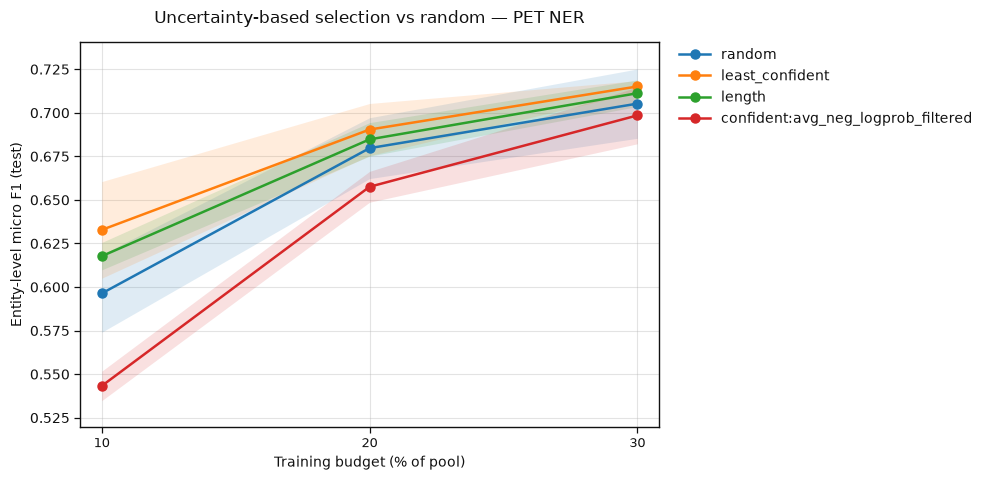

In [23]:
plot_learning_curve(results, RUN_DIR / "learning_curve.png", show=True)

# Cross-run analysis

In [24]:
SPREAD = "nhr_gpt_oss_random_spread"  # the all-random run: the selection-noise band

RUNS = {
    stem: pd.read_csv(latest_run(stem) / "results.csv").assign(run=stem) for stem in run_dirs()
}
results_all = pd.concat(RUNS.values(), ignore_index=True)

print(f"{len(RUNS)} runs, {len(results_all)} trained cells")
sorted(RUNS)

15 runs, 1830 trained cells


['nhr_gemma4_10shot',
 'nhr_gemma4_1shot',
 'nhr_gemma4_1shot_1n_samples',
 'nhr_gemma4_1shot_seed1',
 'nhr_gemma4_1shot_seed7',
 'nhr_gemma4_2shot',
 'nhr_gemma4_5shot',
 'nhr_gemma4_bert',
 'nhr_gemma4_distilbert_uncased',
 'nhr_gemma4_early_stopping',
 'nhr_gemma4_roberta',
 'nhr_gpt_oss_random_spread',
 'nhr_gpt_oss_topk',
 'nhr_kimi2.6_topk',
 'nhr_mistral3.5']

In [25]:
spread = RUNS[SPREAD]
band = {}
for budget, at in spread.groupby("budget_pct"):
    per_draw = at.groupby("arm")["entity_f1"].mean()  # one number per random draw
    seed_sd = at.groupby("arm")["entity_f1"].std().mean()  # noise within a draw
    band[budget] = {
        "draw_sd": per_draw.std(),
        "seed_sd": seed_sd,
        "ratio": per_draw.std() / seed_sd,
        "lo": per_draw.min(),
        "hi": per_draw.max(),
    }

band_df = pd.DataFrame(band).T.rename_axis("budget_pct")
band_df.round(4)

,draw_sd,seed_sd,ratio,lo,hi
budget_pct,,,,,
10.0,0.0445,0.0144,3.0849,0.5046,0.6423
20.0,0.0247,0.0129,1.9096,0.6118,0.6925
30.0,0.0107,0.0140,0.7690,0.6978,0.7259


In [26]:
rows = []
for stem, df in RUNS.items():
    if stem == SPREAD:
        continue
    means = df.groupby(["budget_pct", "arm"])["entity_f1"].mean()
    for budget in df["budget_pct"].unique():
        at = means.loc[budget]
        for arm, f1 in at.items():
            if arm == "random":
                continue
            rows.append(
                {
                    "run": stem,
                    "budget_pct": budget,
                    "arm": arm,
                    "gap": f1 - at["random"],
                    "arm_f1": f1,
                    "random_f1": at["random"],
                    "band": band[min(band, key=lambda b: abs(b - budget))]["draw_sd"],
                }
            )

gaps = pd.DataFrame(rows)
gaps["clears_band"] = gaps["gap"] > gaps["band"]

print(f"{len(gaps)} (run, budget, arm) gaps")
print(f"  positive: {(gaps['gap'] > 0).mean():.0%}   mean {gaps['gap'].mean():+.4f}")
print(f"  clearing the draw-to-draw band: {gaps['clears_band'].sum()} ({gaps['clears_band'].mean():.0%})")
print("  — pure noise centred on zero would put ~16% above +1 sd, so this is not a signal\n")

gaps.groupby("arm")["gap"].agg(["mean", "std", "min", "max", "count"]).sort_values("mean").round(4)

381 (run, budget, arm) gaps
  positive: 40%   mean -0.0217
  clearing the draw-to-draw band: 40 (10%)
  — pure noise centred on zero would put ~16% above +1 sd, so this is not a signal



,mean,std,min,max,count
arm,,,,,
confident:avg_neg_logprob_filtered,-0.0561,0.0412,-0.1766,0.0132,57
avg_neg_logprob_filtered,-0.0328,0.0666,-0.4712,0.0592,57
pairwise_f1_disagreement,-0.0234,0.0600,-0.3004,0.0567,51
vote_entropy,-0.0143,0.0459,-0.2330,0.0513,51
entity_count_std,-0.0124,0.0725,-0.3194,0.1493,51
least_confident,-0.0122,0.0589,-0.2599,0.1107,57
length,0.0010,0.0416,-0.1290,0.0445,57


In [27]:
AXES = {
    "encoder": ["nhr_gemma4_1shot", 
                "nhr_gemma4_bert", 
                "nhr_gemma4_roberta",
                "nhr_gemma4_distilbert_uncased"],

    "few-shot count": ["nhr_gemma4_1shot", 
                       "nhr_gemma4_2shot", 
                       "nhr_gemma4_5shot",
                       "nhr_gemma4_10shot"],

    "example seed": ["nhr_gemma4_1shot", 
                     "nhr_gemma4_1shot_seed1", 
                     "nhr_gemma4_1shot_seed7"],

    "LLM": ["nhr_gemma4_1shot", 
            "nhr_gpt_oss_topk", 
            "nhr_kimi2.6_topk", 
            "nhr_mistral3.5"],

    "stopping rule": ["nhr_gemma4_1shot", 
                      "nhr_gemma4_early_stopping"],
}


def axis(name: str) -> pd.DataFrame:
    """Best gap compared to random F1."""
    sub = gaps[gaps["run"].isin(AXES[name])]
    out = sub.groupby(["run", "budget_pct"]).agg(
        random_f1=("random_f1", "first"),
        mean_gap=("gap", "mean"),
        best_gap=("gap", "max"),
        best_arm=("gap", lambda s: sub.loc[s.idxmax(), "arm"]),
    )
    return out.round(4)

In [28]:
# --- is "uncertain" a property of the sentence, or of the model asked? -----------
# The gaps above say the metrics do not help. This says why: if two LLMs scoring the
# same 332 sentences disagree about which are hardest, there is no sentence-level
# property being measured for a downstream model to benefit from.
from itertools import combinations


def selection_overlap(stems: list[str], metric: str, budget: str = "10") -> float:
    """Mean pairwise overlap of the sentences `metric` selects across runs."""
    picks = []
    for stem in stems:
        sel = json.loads((latest_run(stem) / "selection.json").read_text())
        picks.append(set(sel[budget][metric]))
    return st.fmean(len(a & b) / len(a) for a, b in combinations(picks, 2))


METRICS = ["avg_neg_logprob_filtered", "vote_entropy", "least_confident", "entity_count_std"]
overlap = pd.DataFrame(
    {
        "across LLMs": {m: selection_overlap(AXES["LLM"], m) for m in METRICS},
        "across few-shot examples": {m: selection_overlap(AXES["example seed"], m) for m in METRICS},
        "across few-shot counts": {m: selection_overlap(AXES["few-shot count"], m) for m in METRICS},
    }
)
# 33 of 332 sentences, so two unrelated selections share ~10% by chance.
overlap.loc["(chance)"] = 33 / 332
overlap.style.format("{:.0%}")

,across LLMs,across few-shot examples,across few-shot counts
avg_neg_logprob_filtered,16%,30%,19%
vote_entropy,23%,36%,29%
least_confident,29%,32%,37%
entity_count_std,29%,35%,29%
(chance),10%,10%,10%


In [29]:
# --- was the fixed 20-epoch recipe doing some of the choosing? -------------------
# nhr_gemma4_early_stopping holds 20% of each cell's own budget out and stops on
# validation loss, with epochs=100 as a ceiling. `best_epoch` is where each cell
# actually wanted to stop; the other fourteen runs all train exactly 20.
es = RUNS["nhr_gemma4_early_stopping"]
stopping = es.groupby("budget_pct")[["n_fit", "n_val", "epochs_run", "best_epoch"]].mean()
print(stopping.round(1).to_string())
print(
    f"\nbest_epoch: min {es['best_epoch'].min():.0f}, median {es['best_epoch'].median():.0f}, "
    f"max {es['best_epoch'].max():.0f}   ceiling reached by {(es['epochs_run'] >= 100).sum()} of {len(es)} cells"
)
# The gaps are the point, not the F1: absolute F1 must fall here because a fifth of
# every budget went to validation instead of training.
axis("stopping rule")

            n_fit  n_val  epochs_run  best_epoch
budget_pct                                      
10.0         27.0    6.0        24.9        14.9
20.0         53.0   13.0        21.5        11.5
30.0         80.0   19.0        20.4        10.4

best_epoch: min 7, median 10, max 46   ceiling reached by 0 of 72 cells


random_f1  mean_gap  best_gap  \
run                       budget_pct                                  
nhr_gemma4_1shot          5.0            0.4874   -0.0751    0.0132   
                          10.0           0.5859   -0.0025    0.0306   
                          15.0           0.6367    0.0000    0.0244   
                          20.0           0.6682    0.0074    0.0348   
                          25.0           0.7015   -0.0097    0.0106   
                          30.0           0.7070    0.0022    0.0213   
nhr_gemma4_early_stopping 10.0           0.5567   -0.0231    0.0156   
                          20.0           0.5983    0.0046    0.0312   
                          30.0           0.6197    0.0194    0.0567   

                                                      best_arm  
run                       budget_pct                            
nhr_gemma4_1shot          5.0                 entity_count_std  
                          10.0                entity_count_std  
                          15.0                    vote_entropy  
                          20.0                          length  
                          25.0        pairwise_f1_disagreement  
                          30.0        pairwise_f1_disagreement  
nhr_gemma4_early_stopping 10.0                entity_count_std  
                          20.0                entity_count_std  
                          30.0        pairwise_f1_disagreement

In [30]:
df_encoder = axis("encoder")

df_encoder[df_encoder.index.get_level_values("budget_pct").isin([10, 20, 30])]

random_f1  mean_gap  best_gap  \
run                           budget_pct                                  
nhr_gemma4_1shot              10.0           0.5859   -0.0025    0.0306   
                              20.0           0.6682    0.0074    0.0348   
                              30.0           0.7070    0.0022    0.0213   
nhr_gemma4_bert               10.0           0.5953   -0.0095    0.0462   
                              20.0           0.6938   -0.0058    0.0176   
                              30.0           0.7176    0.0036    0.0299   
nhr_gemma4_distilbert_uncased 10.0           0.5469    0.0211    0.0671   
                              20.0           0.6728   -0.0078    0.0207   
                              30.0           0.7087   -0.0030    0.0278   
nhr_gemma4_roberta            10.0           0.3829    0.0474    0.1493   
                              20.0           0.6478   -0.0059    0.0281   
                              30.0           0.7247   -0.0199    0.0051   

                                                          best_arm  
run                           budget_pct                            
nhr_gemma4_1shot              10.0                entity_count_std  
                              20.0                          length  
                              30.0        pairwise_f1_disagreement  
nhr_gemma4_bert               10.0                 least_confident  
                              20.0                 least_confident  
                              30.0        pairwise_f1_disagreement  
nhr_gemma4_distilbert_uncased 10.0                 least_confident  
                              20.0        pairwise_f1_disagreement  
                              30.0        pairwise_f1_disagreement  
nhr_gemma4_roberta            10.0                entity_count_std  
                              20.0                 least_confident  
                              30.0        pairwise_f1_disagreement

In [31]:
axis("few-shot count")

random_f1  mean_gap  best_gap  \
run               budget_pct                                  
nhr_gemma4_10shot 5.0            0.4874   -0.2131   -0.0718   
                  10.0           0.6034   -0.0513    0.0092   
                  15.0           0.6347   -0.0075    0.0222   
                  20.0           0.6653   -0.0035    0.0248   
                  25.0           0.7009   -0.0206    0.0008   
                  30.0           0.7148   -0.0179   -0.0027   
nhr_gemma4_1shot  5.0            0.4874   -0.0751    0.0132   
                  10.0           0.5859   -0.0025    0.0306   
                  15.0           0.6367    0.0000    0.0244   
                  20.0           0.6682    0.0074    0.0348   
                  25.0           0.7015   -0.0097    0.0106   
                  30.0           0.7070    0.0022    0.0213   
nhr_gemma4_2shot  5.0            0.4874   -0.1088   -0.0564   
                  10.0           0.5859   -0.0200    0.0242   
                  15.0           0.6367   -0.0093    0.0272   
                  20.0           0.6682    0.0007    0.0271   
                  25.0           0.7045   -0.0078    0.0075   
                  30.0           0.7070    0.0004    0.0129   
nhr_gemma4_5shot  5.0            0.4874   -0.2069   -0.1268   
                  10.0           0.6034   -0.0592    0.0111   
                  15.0           0.6367   -0.0228    0.0229   
                  20.0           0.6619   -0.0151    0.0365   
                  25.0           0.7045   -0.0333   -0.0063   
                  30.0           0.7058   -0.0195    0.0062   

                                              best_arm  
run               budget_pct                            
nhr_gemma4_10shot 5.0         pairwise_f1_disagreement  
                  10.0                          length  
                  15.0                          length  
                  20.0                          length  
                  25.0                          length  
                  30.0                          length  
nhr_gemma4_1shot  5.0                 entity_count_std  
                  10.0                entity_count_std  
                  15.0                    vote_entropy  
                  20.0                          length  
                  25.0        pairwise_f1_disagreement  
                  30.0        pairwise_f1_disagreement  
nhr_gemma4_2shot  5.0         avg_neg_logprob_filtered  
                  10.0                          length  
                  15.0                          length  
                  20.0                          length  
                  25.0                          length  
                  30.0                          length  
nhr_gemma4_5shot  5.0                           length  
                  10.0                          length  
                  15.0                          length  
                  20.0                          length  
                  25.0                          length  
                  30.0                          length

In [32]:
df_seed = axis("example seed")

df_seed[df_seed.index.get_level_values("budget_pct").isin([10])]

,,random_f1,mean_gap,best_gap,best_arm
run,budget_pct,,,,
nhr_gemma4_1shot,10.0,0.5859,-0.0025,0.0306,entity_count_std
nhr_gemma4_1shot_seed1,10.0,0.6057,0.0009,0.0296,entity_count_std
nhr_gemma4_1shot_seed7,10.0,0.6289,-0.0614,-0.0187,entity_count_std


In [33]:
df_llm = axis("LLM")

df_llm[df_llm.index.get_level_values("budget_pct").isin([10, 20, 30])]

random_f1  mean_gap  best_gap  \
run              budget_pct                                  
nhr_gemma4_1shot 10.0           0.5859   -0.0025    0.0306   
                 20.0           0.6682    0.0074    0.0348   
                 30.0           0.7070    0.0022    0.0213   
nhr_gpt_oss_topk 10.0           0.5963   -0.0406    0.0365   
                 20.0           0.6797   -0.0123    0.0206   
                 30.0           0.7053    0.0039    0.0158   
nhr_kimi2.6_topk 10.0           0.5963   -0.0379    0.0097   
                 20.0           0.6797   -0.0133    0.0062   
                 30.0           0.7053    0.0050    0.0232   
nhr_mistral3.5   10.0           0.5874   -0.0391    0.0267   
                 20.0           0.6656   -0.0042    0.0366   
                 30.0           0.7126   -0.0085    0.0151   

                                             best_arm  
run              budget_pct                            
nhr_gemma4_1shot 10.0                entity_count_std  
                 20.0                          length  
                 30.0        pairwise_f1_disagreement  
nhr_gpt_oss_topk 10.0                 least_confident  
                 20.0        avg_neg_logprob_filtered  
                 30.0                entity_count_std  
nhr_kimi2.6_topk 10.0                          length  
                 20.0                          length  
                 30.0        avg_neg_logprob_filtered  
nhr_mistral3.5   10.0                          length  
                 20.0                          length  
                 30.0                entity_count_std

In [34]:
keys = AXES["few-shot count"]

few_shot_df = pd.concat([RUNS[key] for key in keys], ignore_index=True)
few_shot_df['n_shot'] = few_shot_df['run'].str.extract(r'(\d+)shot').astype(int)
few_shot_df

,budget_pct,arm,seed,n_train,entity_f1,entity_precision,entity_recall,token_accuracy,n_fit,n_val,epochs_run,best_epoch,best_val_loss,run,n_shot
0,5.0,random,0,16,0.493827,0.445434,0.554017,0.632919,16,0,20,NaN,NaN,nhr_gemma4_1shot,1
1,5.0,random,1,16,0.481622,0.443925,0.526316,0.633540,16,0,20,NaN,NaN,nhr_gemma4_1shot,1
2,5.0,random,2,16,0.484076,0.448113,0.526316,0.638509,16,0,20,NaN,NaN,nhr_gemma4_1shot,1
3,5.0,random,3,16,0.495000,0.451025,0.548476,0.631677,16,0,20,NaN,NaN,nhr_gemma4_1shot,1
4,5.0,random,4,16,0.482587,0.437923,0.537396,0.635404,16,0,20,NaN,NaN,nhr_gemma4_1shot,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,30.0,confident:avg_neg_logprob_filtered,0,96,0.657177,0.574689,0.767313,0.737888,96,0,20,NaN,NaN,nhr_gemma4_10shot,10
956,30.0,confident:avg_neg_logprob_filtered,1,96,0.673171,0.601307,0.764543,0.766460,96,0,20,NaN,NaN,nhr_gemma4_10shot,10
957,30.0,confident:avg_neg_logprob_filtered,2,96,0.676435,0.604803,0.767313,0.765839,96,0,20,NaN,NaN,nhr_gemma4_10shot,10
958,30.0,confident:avg_neg_logprob_filtered,3,96,0.657005,0.582441,0.753463,0.760248,96,0,20,NaN,NaN,nhr_gemma4_10shot,10


In [35]:
# F1 score vs number of few-shot examples
few_shot_df[few_shot_df['arm'] == 'avg_neg_logprob_filtered'].groupby(['n_shot', 'budget_pct'])['entity_f1'].mean().unstack().round(4)


budget_pct,5.0,10.0,15.0,20.0,25.0,30.0
n_shot,,,,,,
1,0.4529,0.5636,0.6053,0.6354,0.6715,0.7016
2,0.4310,0.5004,0.6173,0.6628,0.6830,0.6972
5,0.3558,0.5366,0.6191,0.6379,0.6701,0.6807
10,0.0163,0.5414,0.6218,0.6441,0.6723,0.6869
